In [111]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, Subset
import numpy as np
import pandas as pd
import pickle
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.optim import Adam
import random
from sklearn.metrics import roc_auc_score
from itertools import product

In [29]:
# GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# Imports para el pickle de DELIGHT (wcs y objects usan astropy)
from astropy.coordinates.representation.geodetic import (
    BaseGeodeticRepresentation,
    WGS84GeodeticRepresentation,
    WGS72GeodeticRepresentation,
    GRS80GeodeticRepresentation
)

import astropy.coordinates.earth as earth_mod
earth_mod.BaseGeodeticRepresentation = BaseGeodeticRepresentation
earth_mod.WGS84GeodeticRepresentation = WGS84GeodeticRepresentation
earth_mod.WGS72GeodeticRepresentation = WGS72GeodeticRepresentation
earth_mod.GRS80GeodeticRepresentation = GRS80GeodeticRepresentation

In [ ]:
# Leemos el archivo pickle de DELIGHT original
delight_file = "DELIGHT/delight.pkl"
df_delight = pd.read_pickle(delight_file)

In [19]:
# Columnas del pickle original
columns = [
    "Index", "ra", "dec", "dist", "filename", "wcs", "sn_coords", "xSN", "ySN",
    "dx", "dy", "data", "objects", "mask", "dx_sex", "dy_sex", "dxdy_delight_rotflip",
    "dx_delight", "dy_delight", "std_delight", "host_coords_delight_pred",
    "host_coords_sex_pred", "ra_delight", "dec_delight", "ra_sex", "dec_sex",
    "hostsize", "hostsep", "mindistsize"
]

df_columns = pd.DataFrame(columns, columns=["Column Name"])

In [20]:
df_columns

,Column Name
0,Index
1,ra
2,dec
3,dist
4,filename
5,wcs
6,sn_coords
7,xSN
8,ySN
9,dx


In [ ]:
# Eliminamos las columnas que no son necesarias para el modelo (todo excepto imagenes y algunos datos utiles)

df = df_delight.reset_index().rename(columns={'index': "oid"})
output_pkl = "DELIGHT/delight_fits.pkl"

drop_cols = [
        'dist',
        'sn_coords',
        'xSN',
        'ySN',
        'dx',
        'dy',
        'dx_sex',
        'dy_sex',
        'dxdy_delight_rotflip',
        'dx_delight',
        'dy_delight',
        'std_delight',
        'host_coords_delight_pred',
        'host_coords_sex_pred',
        'ra_delight',
        'dec_delight',
        'ra_sex',
        'dec_sex',
        'hostsize',
        'hostsep',
        'mindistsize',
        'objects',
        'wcs',
        'mask'
    ]

to_drop = [col for col in drop_cols if col in df.columns]
if to_drop:
    df = df.drop(columns=to_drop)
    print(f"Columnas eliminadas: {to_drop}")
else:
    print("Ninguna de las columnas a eliminar estaba presente.")

with open(output_pkl, 'wb') as f:
    pickle.dump(df, f)
print(f"Pickle limpio guardado en: {output_pkl}")

Columnas eliminadas: ['dist', 'sn_coords', 'xSN', 'ySN', 'dx', 'dy', 'dx_sex', 'dy_sex', 'dxdy_delight_rotflip', 'dx_delight', 'dy_delight', 'std_delight', 'host_coords_delight_pred', 'host_coords_sex_pred', 'ra_delight', 'dec_delight', 'ra_sex', 'dec_sex', 'hostsize', 'hostsep', 'mindistsize', 'objects', 'wcs', 'mask']
Pickle limpio guardado en: DELIGHT/delight_fits.pkl


In [3]:
# Cargamos el pickle con solo las imagenes
delight_file = "DELIGHT/delight_fits.pkl"
df_delight = pd.read_pickle(delight_file)

In [11]:
# Revisamos como acceder a las imagenes dado un oid
example_oid = "ZTF17aabvong"

data_oid = df_delight[df_delight['oid'] == example_oid]['data']

In [ ]:
# Imagen multiresolucion (5 niveles) de 30 x 30
data_oid.values[0].shape

(5, 30, 30)

In [20]:
# Revisamos si hay oids repetidos
duplicates = df_delight['oid'].duplicated().any()
if duplicates:
    print("Hay oids repetidos en el DataFrame.")
else:
    print("No hay oids repetidos en el DataFrame.")

No hay oids repetidos en el DataFrame.


In [ ]:
# Leemos veto_summary y agregamos la columna "label" al df de DELIGHT
veto_summary_file = "tabular_data/veto_summary.csv"
df_veto_summary = pd.read_csv(veto_summary_file)
df_veto_summary = df_veto_summary.rename(columns={'oid': 'oid', 'label': 'label'})
df_delight = df_delight.merge(df_veto_summary[['oid', 'label']], on='oid', how='left')

In [33]:
df_delight

,oid,ra,dec,filename,data,label
0,ZTF22aaaolwx,230.351159,54.250215,stack_r_ra230.351159_dec54.250215_arcsec120.fits,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",NaN
1,ZTF22aaaxmix,235.212955,13.226248,stack_r_ra235.212955_dec13.226248_arcsec120.fits,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",NaN
2,ZTF22aabgasm,244.949052,8.071116,stack_r_ra244.949052_dec8.071116_arcsec120.fits,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",NaN
3,ZTF22aabwuks,203.220651,29.953070,stack_r_ra203.220651_dec29.953070_arcsec120.fits,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",NaN
4,ZTF22aabwuae,202.636665,30.546504,stack_r_ra202.636665_dec30.546504_arcsec120.fits,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",NaN
...,...,...,...,...,...,...
19965,ZTF23abhkkcv,20.503617,2.779283,stack_r_ra20.503617_dec2.779283_arcsec120.fits,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",good
19966,ZTF23abhfhze,13.003263,9.481944,stack_r_ra13.003263_dec9.481944_arcsec120.fits,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",good
19967,ZTF23abhdcct,259.063642,37.111388,stack_r_ra259.063642_dec37.111388_arcsec120.fits,"[[[0.4332476854324341, 0.4368361830711365, 0.4...",bad
19968,ZTF23abheflz,350.091240,33.087213,stack_r_ra350.091240_dec33.087213_arcsec120.fits,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",good


In [ ]:
# En DELIGHT se incluyen oids que no tienen vetos (por lo que no tienen label)
# Dropeamos los que tengan label NaN
df_delight_clean = df_delight.dropna(subset=['label'])
df_delight_clean = df_delight_clean.reset_index(drop=True)


In [35]:
df_delight_clean

,oid,ra,dec,filename,data,label
0,ZTF22aaohvay,213.149964,30.588487,stack_r_ra213.149964_dec30.588487_arcsec120.fits,"[[[0.09362327307462692, 0.1381927728652954, 0....",bad
1,ZTF23abhaxcd,160.068530,40.112313,stack_r_ra160.068530_dec40.112313_arcsec120.fits,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.201849...",good
2,ZTF23abhbjzb,157.340492,40.998869,stack_r_ra157.340492_dec40.998869_arcsec120.fits,"[[[0.0, 0.0, 0.1351906955242157, 0.18911431729...",good
3,ZTF23abhbpmc,156.379115,37.357226,stack_r_ra156.379115_dec37.357226_arcsec120.fits,"[[[0.17190486192703247, 0.17222090065479279, 0...",good
4,ZTF23abhbzbo,115.689564,47.412348,stack_r_ra115.689564_dec47.412348_arcsec120.fits,"[[[0.21823176741600037, 0.20457853376865387, 0...",good
...,...,...,...,...,...,...
19756,ZTF23abhkkcv,20.503617,2.779283,stack_r_ra20.503617_dec2.779283_arcsec120.fits,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",good
19757,ZTF23abhfhze,13.003263,9.481944,stack_r_ra13.003263_dec9.481944_arcsec120.fits,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",good
19758,ZTF23abhdcct,259.063642,37.111388,stack_r_ra259.063642_dec37.111388_arcsec120.fits,"[[[0.4332476854324341, 0.4368361830711365, 0.4...",bad
19759,ZTF23abheflz,350.091240,33.087213,stack_r_ra350.091240_dec33.087213_arcsec120.fits,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",good


In [45]:
# Guardamos el DataFrame limpio
output_clean_pkl = "DELIGHT/delight_clean.pkl"
with open(output_clean_pkl, 'wb') as f:
    pickle.dump(df_delight_clean, f)
print(f"DataFrame limpio guardado en: {output_clean_pkl}")

DataFrame limpio guardado en: DELIGHT/delight_clean.pkl


In [4]:
# Cargamos el DataFrame limpio
with open("DELIGHT/delight_clean.pkl", 'rb') as f:
    df_delight_clean = pickle.load(f)
# Revisamos las primeras filas del DataFrame limpio
df_delight_clean.head()

,oid,ra,dec,filename,data,label
0,ZTF22aaohvay,213.149964,30.588487,stack_r_ra213.149964_dec30.588487_arcsec120.fits,"[[[0.09362327307462692, 0.1381927728652954, 0....",bad
1,ZTF23abhaxcd,160.068530,40.112313,stack_r_ra160.068530_dec40.112313_arcsec120.fits,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.201849...",good
2,ZTF23abhbjzb,157.340492,40.998869,stack_r_ra157.340492_dec40.998869_arcsec120.fits,"[[[0.0, 0.0, 0.1351906955242157, 0.18911431729...",good
3,ZTF23abhbpmc,156.379115,37.357226,stack_r_ra156.379115_dec37.357226_arcsec120.fits,"[[[0.17190486192703247, 0.17222090065479279, 0...",good
4,ZTF23abhbzbo,115.689564,47.412348,stack_r_ra115.689564_dec47.412348_arcsec120.fits,"[[[0.21823176741600037, 0.20457853376865387, 0...",good


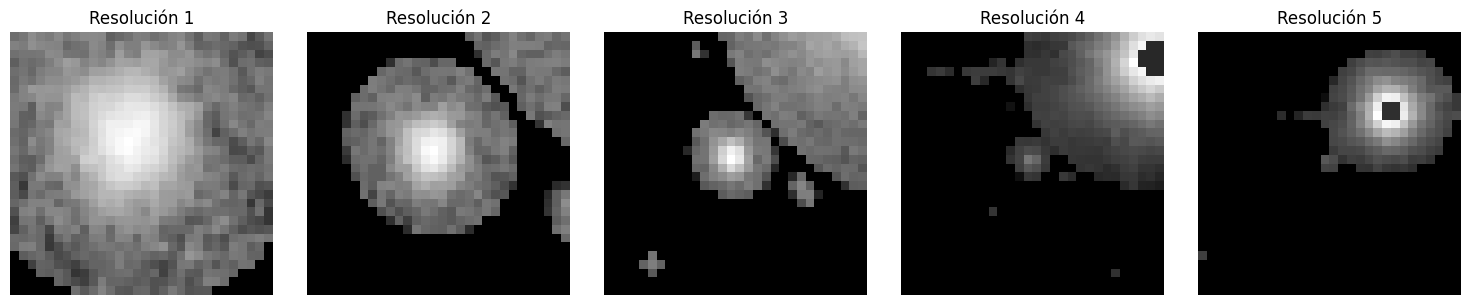

In [6]:
# Visualizamos los fits del oid de ejemplo desde el DataFrame limpio
# Plot de las 5 resoluciones de la imagen del oid
example_oid = "ZTF23abhaxcd"
fits_data = df_delight_clean[df_delight_clean['oid'] == example_oid]['data'].values[0]
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    ax = axes[i]
    ax.imshow(fits_data[i], cmap='gray', origin='lower')
    ax.set_title(f'Resolución {i+1}')
    ax.axis('off')
plt.tight_layout()
plt.show()


In [11]:
# Optimizacion de formato de los datos
df = df_delight_clean.copy()
df['data_arr'] = df['data'].apply(lambda lst: np.array(lst, dtype=np.float32))

In [ ]:
# Convertimos las imagenes a tensores y las etiquetas a listas
data_list = df['data_arr'].tolist()
labels = df['label'].map({'bad': 0, 'good': 1}).to_list()

In [ ]:
# Normalizacion OJO, usa una cualquiera, hay que adaptarlo al problema !!!!!!!!!!!!!!
all_data = np.stack(data_list, axis=0)        # (N,5,30,30)
# Buscamos la media y desviacion estandar por canal (asi me lo recomendo el GPT)
means = all_data.mean(axis=(0,2,3)).tolist()
stds  = all_data.std(axis=(0,2,3)).tolist()
normalize = transforms.Normalize(mean=means, std=stds)

In [ ]:
# Convertir a tensor y aplicar Normalize a todos
tensor_data = torch.stack([
    normalize(torch.from_numpy(arr)) 
    for arr in data_list
], dim=0)

tensor_labels = torch.tensor(labels, dtype=torch.float32)

In [23]:
"""
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tensor_data = tensor_data.to(device)
tensor_labels = tensor_labels.to(device)
"""

"\ndevice = torch.device('cuda' if torch.cuda.is_available() else 'cpu')\ntensor_data = tensor_data.to(device)\ntensor_labels = tensor_labels.to(device)\n"

In [ ]:
# Creamos el Dataset como Tensor
dataset = TensorDataset(tensor_data, tensor_labels)

In [73]:
# K folds estratisficados
splits = pd.read_csv('folds/stratified_folds.csv')  

In [75]:
def get_fold_indices(df, fold):
    train_col = f'train_fold{fold}'
    val_col   = f'val_fold{fold}'
    train_idx = df.loc[df[train_col]==1, 'orig_idx'].tolist()
    val_idx   = df.loc[df[val_col]==1,   'orig_idx'].tolist()
    return train_idx, val_idx

In [ ]:
# Juntamos los datos con el split
df_merged = df_delight_clean.reset_index().merge(
    splits, on='oid', how='inner'
)

df_merged = df_merged.rename(columns={'index':'orig_idx'})

In [ ]:
# Definimos el loader
loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

In [ ]:
# Clase CNN para una sola resolución de Delight (entrada 1x30x30).
# Para el entrenamiento de una sola rama (resolución) de Delight.
# Hay que entrenar aqui 5 modelos con la misma arquitectura (pesos distintos para cada resolución)
class DelightCNN(nn.Module):
    """
    Rama de CNN para una sola resolución de Delight (entrada 1x30x30).
    Arquitectura simple para extracción de features.
    """
    def __init__(self, out_features: int = 64, dropout: float = 0.3):
        super(DelightCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1,
                               out_channels=16,
                               kernel_size=5,
                               stride=1,
                               padding=2)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(in_channels=16,
                               out_channels=32,
                               kernel_size=3,
                               stride=1,
                               padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        # Cálculo del tamaño tras dos poolings 30x30 -> 15x15 -> 7x7
        flat_size = 32 * 7 * 7
        # Capas fully-connected para reducir a out_features
        self.fc1 = nn.Linear(flat_size, 128)
        self.fc2 = nn.Linear(128, out_features)
        # Dropout ligero para regularización
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.
        Args:
            x: tensor de entrada con forma (batch_size, 1, 30, 30)
        Returns:
            Tensor de features de dimensión (batch_size, out_features)
        """
        # Bloque conv1 + BN + ReLU + MaxPool
        x = F.relu(self.bn1(self.conv1(x)))   # -> (16, 30, 30)
        x = F.max_pool2d(x, kernel_size=2)     # -> (16, 15, 15)
        # Bloque conv2 + BN + ReLU + MaxPool
        x = F.relu(self.bn2(self.conv2(x)))   # -> (32, 15, 15)
        x = F.max_pool2d(x, kernel_size=2)     # -> (32, 7, 7)
        # Aplanamos para FC
        x = x.view(x.size(0), -1)             # -> (batch, 32*7*7)
        # Fully connected + ReLU + Dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        # Capa final de features
        features = self.fc2(x)
        return features

In [ ]:
# Resolucion a entrenar y numero de epochs (bajo para gridsearch)
num_epochs = 3
branch_idx = 0

In [124]:
"""
param_grid = {
    'lr':        [1e-3, 5e-4, 1e-4],
    'batch_size':[8, 16, 32],
    'dropout':   [0.0, 0.3, 0.5],
}
"""
param_grid = {
    'lr':        [1e-3],
    'batch_size':[16, 32],
    'dropout':   [0.3, 0.5],
}

In [125]:
best_auc    = -float('inf')
best_params = None

In [126]:
# Loop de CV y gridsearch
# Iteramos sobre combinaciones de hiperparámetros
for lr, batch_size, dropout in product(param_grid['lr'], param_grid['batch_size'], param_grid['dropout']):

    cv_aucs = []
    
    # 5‑fold CV
    for fold in range(1, 6):
        # indices de train/val
        train_idx, val_idx = get_fold_indices(df_merged, fold)

        # DataLoaders
        tr_loader = DataLoader(Subset(dataset, train_idx),
                               batch_size=batch_size, shuffle=True,
                               pin_memory=True, num_workers=2,
                               persistent_workers=True)
        vl_loader = DataLoader(Subset(dataset, val_idx),
                               batch_size=batch_size, shuffle=False,
                               pin_memory=True, num_workers=2,
                               persistent_workers=True)

        # Instancia de modelo
        model = DelightCNN(out_features=1, dropout=dropout).to(device)
        optim  = torch.optim.Adam(model.parameters(), lr=lr)
        crit   = nn.BCEWithLogitsLoss()

        # n epocas de entrenamiento
        for epoch in range(num_epochs):
            model.train()
            for data, labels in tr_loader:
                x = data[:, branch_idx:branch_idx+1].to(device, non_blocking=True)
                y = labels.to(device, non_blocking=True)
                optim.zero_grad()
                loss = crit(model(x).squeeze(), y)
                loss.backward()
                optim.step()

        # Validamos
        model.eval()
        all_logits, all_labels = [], []
        with torch.no_grad():
            for data, labels in vl_loader:
                x = data[:, branch_idx:branch_idx+1].to(device, non_blocking=True)
                logits = model(x).squeeze().cpu()
                all_logits.append(logits)
                all_labels.append(labels)
        logits = torch.cat(all_logits)
        labels = torch.cat(all_labels)
        cv_aucs.append(roc_auc_score(labels, torch.sigmoid(logits)))

    mean_auc = sum(cv_aucs) / len(cv_aucs)
    print(f"lr={lr}, batch={batch_size}, drop={dropout} → AUC={mean_auc:.4f}")

    if mean_auc > best_auc:
        best_auc    = mean_auc
        best_params = (lr, batch_size, dropout)

print("Mejores params CNN:", best_params, "AUC:", best_auc)

lr=0.001, batch=16, drop=0.3 → AUC=0.7746
lr=0.001, batch=16, drop=0.5 → AUC=0.7735
lr=0.001, batch=32, drop=0.3 → AUC=0.7750
lr=0.001, batch=32, drop=0.5 → AUC=0.7758
Mejores params CNN: (0.001, 32, 0.5) AUC: 0.7757703811491942


In [145]:
# Probamos la CNN
dataset = loader.dataset

idx = random.randrange(len(dataset))
data, label = dataset[idx]

branch_idx = 0
single = data[branch_idx]            
single = single.unsqueeze(0).unsqueeze(0)
single = single.to(device)              

# Inferencia
model.eval()
with torch.no_grad():
    logit = model(single).squeeze()
    prob  = torch.sigmoid(logit).item() 

print(f"Índice muestreado: {idx}")
print(f"Etiqueta real    : {int(label.item())} ({'good' if label.item()==1 else 'bad'})")
print(f"Probabilidad 'good': {prob:.4f}")
print(f"Predicción       : { 'good' if prob>0.5 else 'bad' }")

Índice muestreado: 7624
Etiqueta real    : 0 (bad)
Probabilidad 'good': 0.8057
Predicción       : good
